# Seasonality in quasi-experimental time series

Many outcomes follow seasonal patterns: retail sales rise before holidays, energy demand follows the weather, and job postings often dip over the December holidays before recovering in January. If the intervention date lines up with a seasonal high or low, a model that ignores seasonality can mistake the seasonal swing for a causal effect.

How to account for seasonality depends on the design:

- In {term}`ITS <Interrupted time series design>`, the model has to capture seasonality explicitly, for example with Fourier terms or seasonal dummies in the model formula.
- In {term}`CITS <Comparative interrupted time-series>` and {term}`synthetic control <Synthetic control>`, control or donor units absorb the seasonality they share with the treated unit, but not seasonality that is specific to the treated unit.
- Structural time series models estimate a seasonal component as part of the model.

This notebook works through these cases with simulated data in which **the true effect is zero**. Any systematic estimated effect is therefore bias.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

import causalpy as cp

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
seed = 42
rng = np.random.default_rng(seed)

## Simulated data

We simulate weekly observations from January 2021 to March 2026: a linear trend, a yearly seasonal pattern, and noise. The seasonal pattern has a sharp peak in winter, sharper than a sine wave, so no finite number of Fourier terms reproduces it exactly. The treatment date is 1 December 2025, so the post-intervention period (December to March) falls in the seasonal high. The data contain no treatment effect.

In [3]:
ORIGIN = pd.Timestamp("2021-01-01")
YEAR_DAYS = 365.25
treatment_time = pd.Timestamp("2025-12-01")

dates = pd.date_range("2021-01-03", "2026-03-29", freq="W-SUN")
t = np.arange(len(dates))
phase = 2 * np.pi * (dates - ORIGIN).days.to_numpy() / YEAR_DAYS
winter_peak = np.exp(2 * np.cos(phase))
seasonal = 1.8 * (winter_peak - winter_peak.mean())

df = pd.DataFrame(
    {
        "y": 100 + 0.03 * t + seasonal + rng.normal(0, 1.5, len(dates)),
        "t": t,
        "month": dates.month,
    },
    index=pd.DatetimeIndex(dates, name="date"),
)
df.head()

,y,t,month
date,,,
2021-01-03,109.463834,0,1
2021-01-10,107.178121,1,1
2021-01-17,109.243688,2,1
2021-01-24,108.619177,3,1
2021-01-31,103.166013,4,1


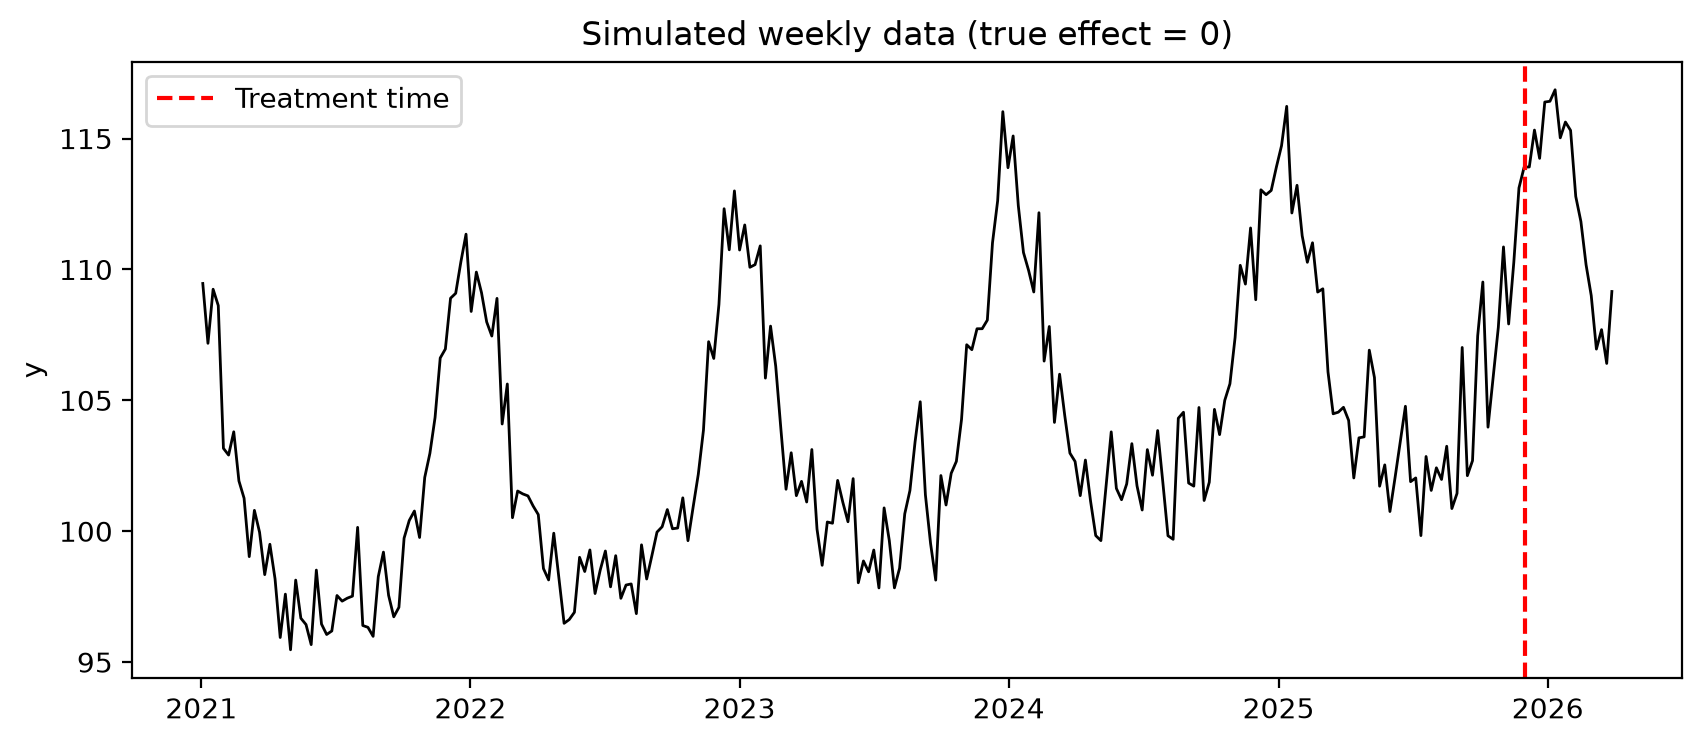

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index, df["y"], color="k", lw=1)
ax.axvline(treatment_time, color="r", ls="--", label="Treatment time")
ax.set(ylabel="y", title="Simulated weekly data (true effect = 0)")
ax.legend();

The notebook fits many models, so two small helpers keep the code short: one fits an ITS model with a Bayesian linear regression, and one extracts the average post-intervention effect with its 95% HDI.

In [5]:
def fit_its(data, formula, treatment=treatment_time):
    """Fit an interrupted time series model with a Bayesian linear regression."""
    return cp.InterruptedTimeSeries(
        data,
        treatment,
        formula=formula,
        model=cp.pymc_models.LinearRegression(
            sample_kwargs={"random_seed": seed, "progressbar": False}
        ),
    ).fit()


def average_effect(result, **kwargs):
    """Average post-intervention effect with its 95% HDI."""
    table = result.effect_summary(direction="two-sided", **kwargs).table
    return table.loc["average", ["mean", "hdi_lower", "hdi_upper"]]

## ITS without seasonal terms

First, fit an ITS model with only an intercept and a linear trend.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


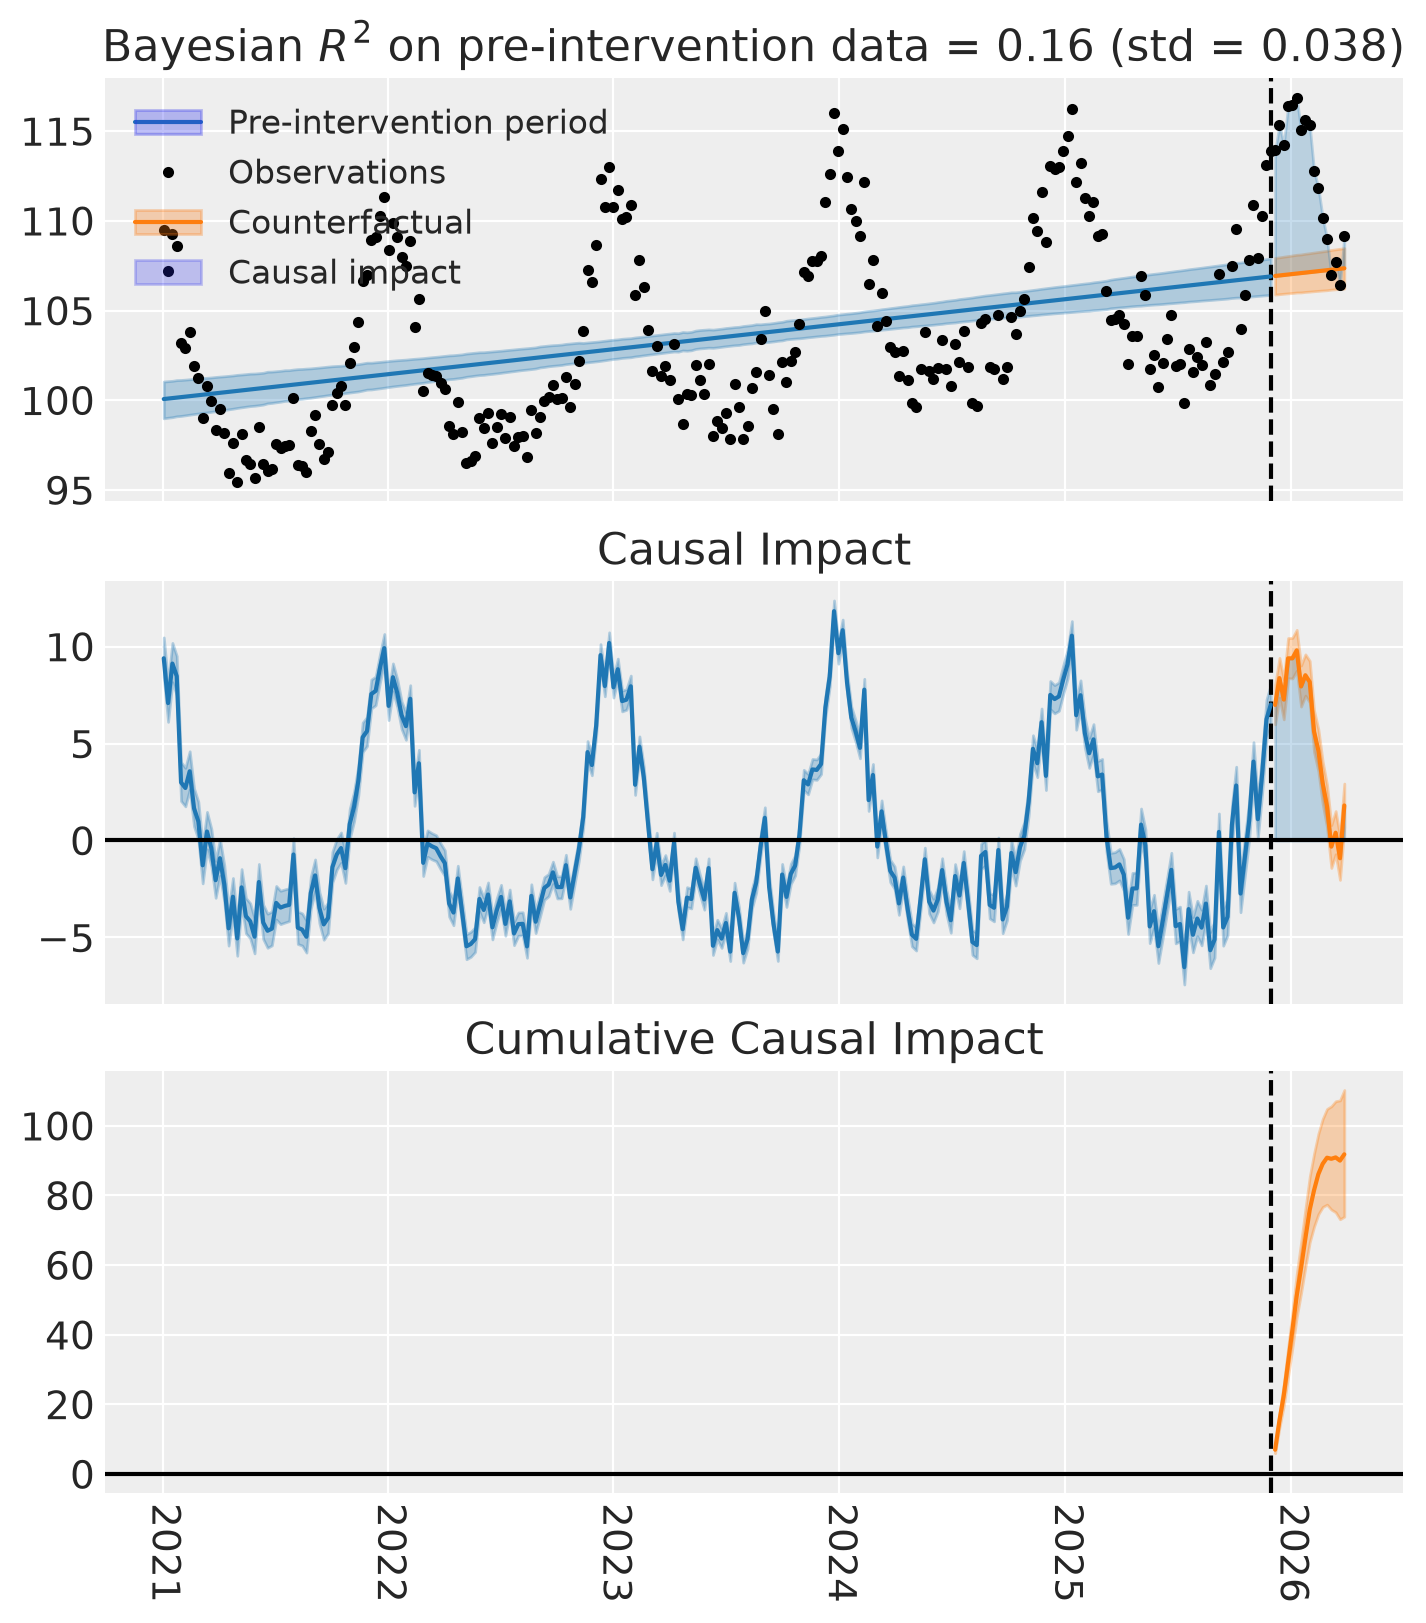

In [6]:
result_trend = fit_its(df, "y ~ 1 + t")
fig, ax = result_trend.plot()

In [7]:
pd.DataFrame({"No seasonality": average_effect(result_trend)}).T.round(2)

,mean,hdi_lower,hdi_upper
No seasonality,5.4,4.34,6.58


The model reports a clear positive effect even though none exists. The top panel shows why: the observations swing above and below the fitted trend with the seasons, and the post-intervention period falls in the seasonal high. The trend-only {term}`counterfactual <Counterfactual>` cannot follow that swing, so the gap between the observed data and the counterfactual is attributed to the treatment.

Part of the bias also comes through the trend. The pre-intervention period does not cover a whole number of years, so the omitted seasonal swing pulls the estimated slope away from its true value of 0.03:

In [8]:
slope = result_trend.idata.posterior["beta"].sel(coeffs="t").mean().item()
print(f"true slope: 0.030, estimated slope: {slope:.4f}")

true slope: 0.030, estimated slope: 0.0267


## Adding Fourier terms

Fourier terms represent a periodic pattern as a sum of sine and cosine pairs at multiples of the yearly frequency:

$$
s(t) = \sum_{k=1}^{K} \left[ a_k \sin\left(\frac{2\pi k \, d(t)}{365.25}\right) + b_k \cos\left(\frac{2\pi k \, d(t)}{365.25}\right) \right]
$$

where $d(t)$ is the number of days since a fixed origin (here 1 January 2021), and $a_k$ and $b_k$ are coefficients the model estimates. With $K$ pairs the model gains $2K$ parameters, compared with more than 50 for week-of-year dummies, and the seasonal pattern stays smooth. Larger values of $K$ allow sharper seasonal shapes. Because the terms are built from the date rather than the row number, they cope with years that have 53 weeks and have no jump at the new year.

The terms are ordinary columns, so they enter the model formula like any other predictor.

In [9]:
def fourier_features(index, order, origin=ORIGIN, period=YEAR_DAYS):
    """Return `order` sine/cosine pairs for yearly seasonality as a DataFrame."""
    phase = 2 * np.pi * (index - origin).days.to_numpy() / period
    columns = {}
    for k in range(1, order + 1):
        columns[f"sin{k}"] = np.sin(k * phase)
        columns[f"cos{k}"] = np.cos(k * phase)
    return pd.DataFrame(columns, index=index)


def fourier_formula(lhs, order, base="1 + t"):
    """Model formula with `order` Fourier pairs added to `base`."""
    terms = [f"{p}{k}" for k in range(1, order + 1) for p in ("sin", "cos")]
    return f"{lhs} ~ " + " + ".join([base, *terms])


df = df.join(fourier_features(df.index, order=8))
fourier_formula("y", 2)

'y ~ 1 + t + sin1 + cos1 + sin2 + cos2'

### Choosing the number of pairs

Choose $K$ using the **pre-intervention data only**. Using post-intervention data would tune the model to the effect you are trying to estimate.

A quick, pragmatic check is to compare an information criterion across values of $K$. {cite:t}`hyndman2021forecasting` choose $K$ by minimizing the corrected AIC, AICc ([section 10.5](https://otexts.com/fpp3/dhr.html)). Here we compute both AIC and AICc from an ordinary least squares fit in `statsmodels`.

In [10]:
pre = df[df.index < treatment_time]
rows = {}
for k in range(9):
    fit = smf.ols(fourier_formula("y", k), data=pre).fit()
    n_params = len(fit.params)
    aicc = fit.aic + 2 * n_params * (n_params + 1) / (fit.nobs - n_params - 1)
    rows[k] = {"AIC": fit.aic, "AICc": aicc}
criteria = pd.DataFrame(rows).T.rename_axis("K")
k_best = int(criteria["AICc"].to_numpy().argmin())  # rows are K = 0, 1, ..., 8
criteria.round(1)

,AIC,AICc
K,,
0,1503.1,1503.1
1,1147.3,1147.5
2,953.6,953.9
3,919.2,919.8
4,919.6,920.4
5,923.3,924.6
6,926.6,928.4
7,928.1,930.3
8,930.6,933.5


Both criteria are lowest at $K=3$, with $K=4$ close behind. Because the true winter peak is sharper than any finite sum of waves, there is no "correct" $K$: the criterion picks the point where extra pairs stop paying for themselves.

These criteria treat the residuals as independent. With real data the residuals are often autocorrelated, which tends to favor too many terms; leave-future-out cross-validation respects the time order but is more work. Either way, check the pre-intervention residuals for leftover seasonal structure, as shown below.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


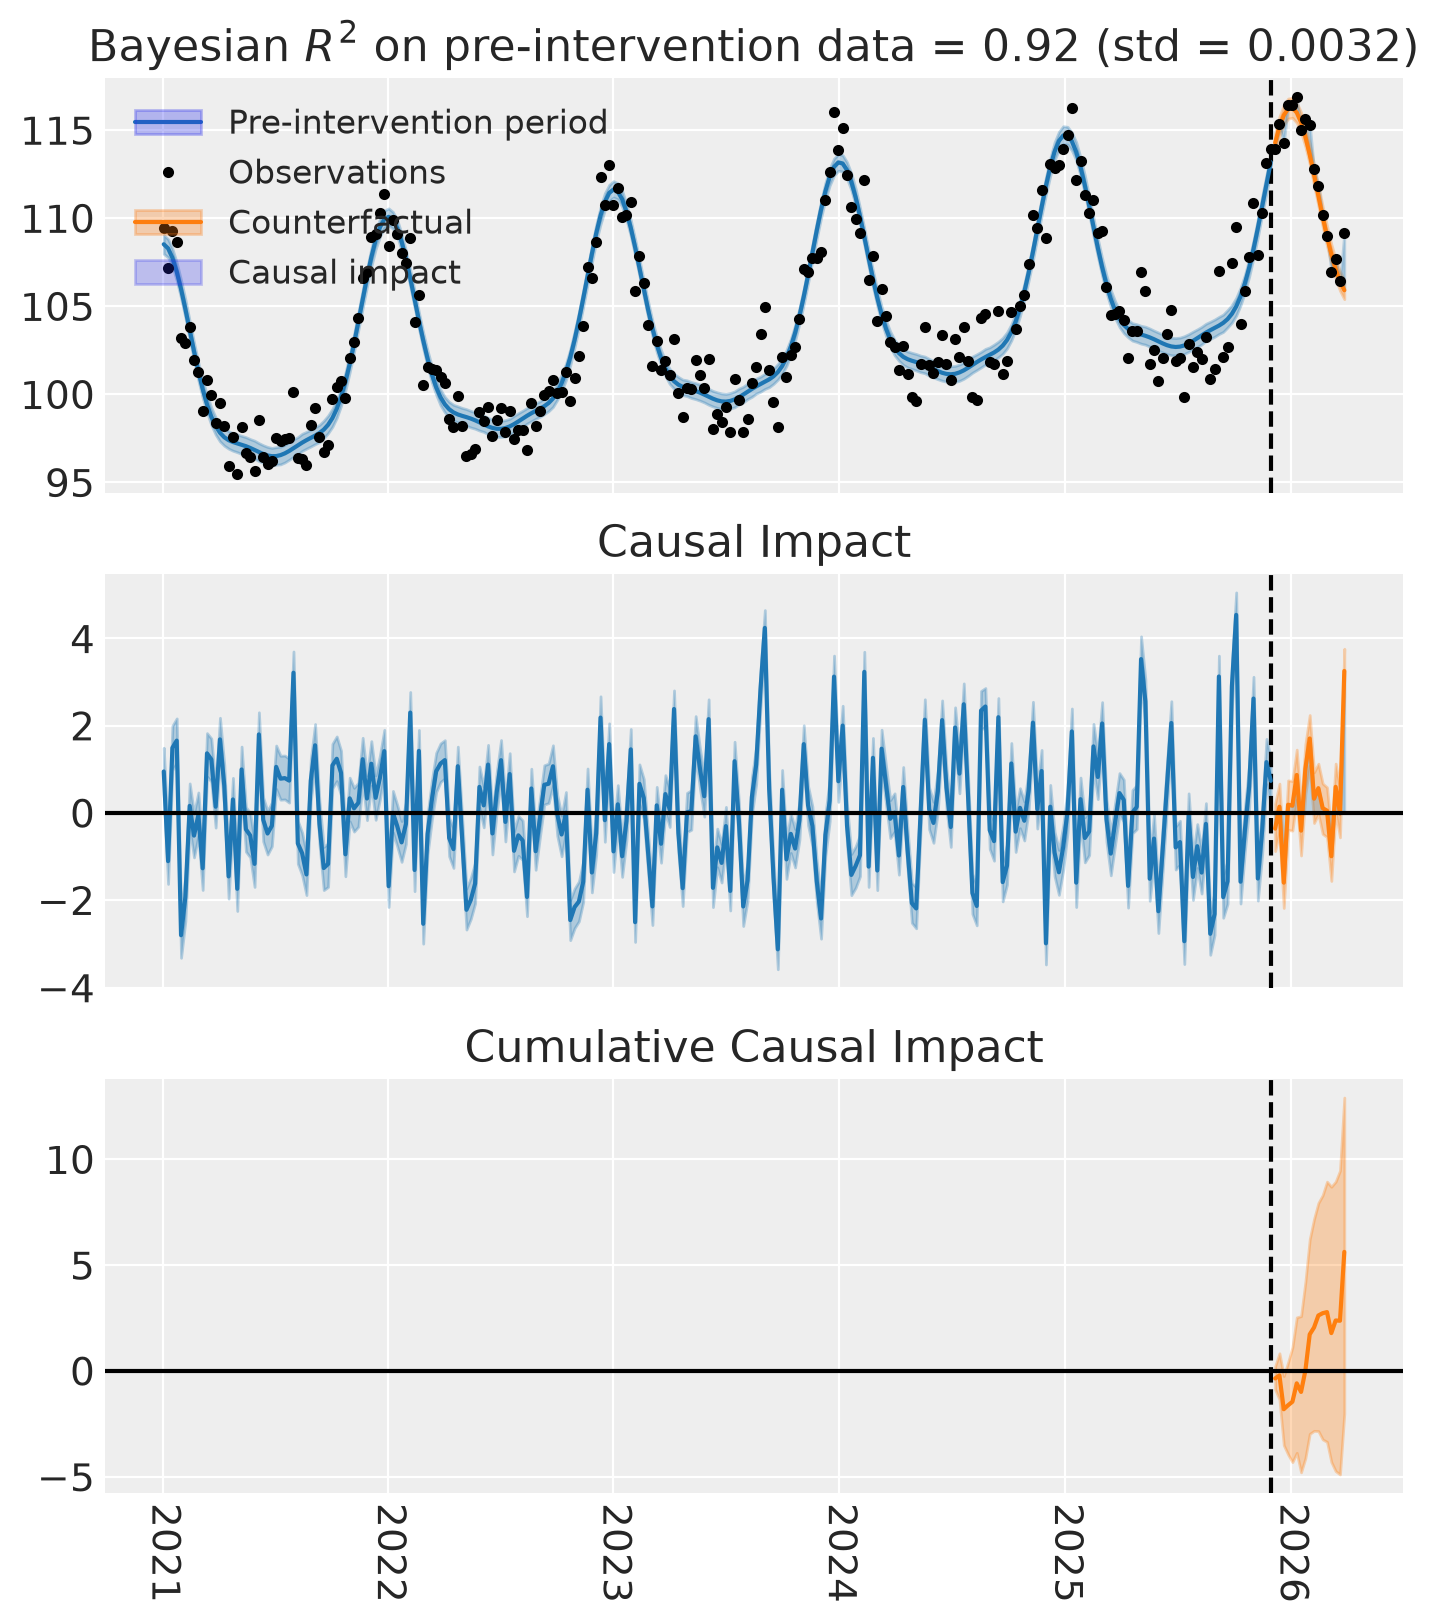

In [11]:
result_fourier = fit_its(df, fourier_formula("y", k_best))
fig, ax = result_fourier.plot()

In [12]:
pd.DataFrame({f"Fourier, K={k_best}": average_effect(result_fourier)}).T.round(2)

,mean,hdi_lower,hdi_upper
"Fourier, K=3",0.33,-0.16,0.77


With seasonality in the model, the counterfactual follows the seasonal high, the estimated effect is close to zero, and its interval includes zero.

### Checking the pre-intervention residuals

A model that captures the seasonality leaves no seasonal pattern in its pre-intervention residuals. `get_plot_data` returns the observed data with the posterior mean prediction and the `impact` column (observed minus predicted); in the pre-intervention period, `impact` is the residual. Averaging it by calendar month makes leftover seasonality easy to see.

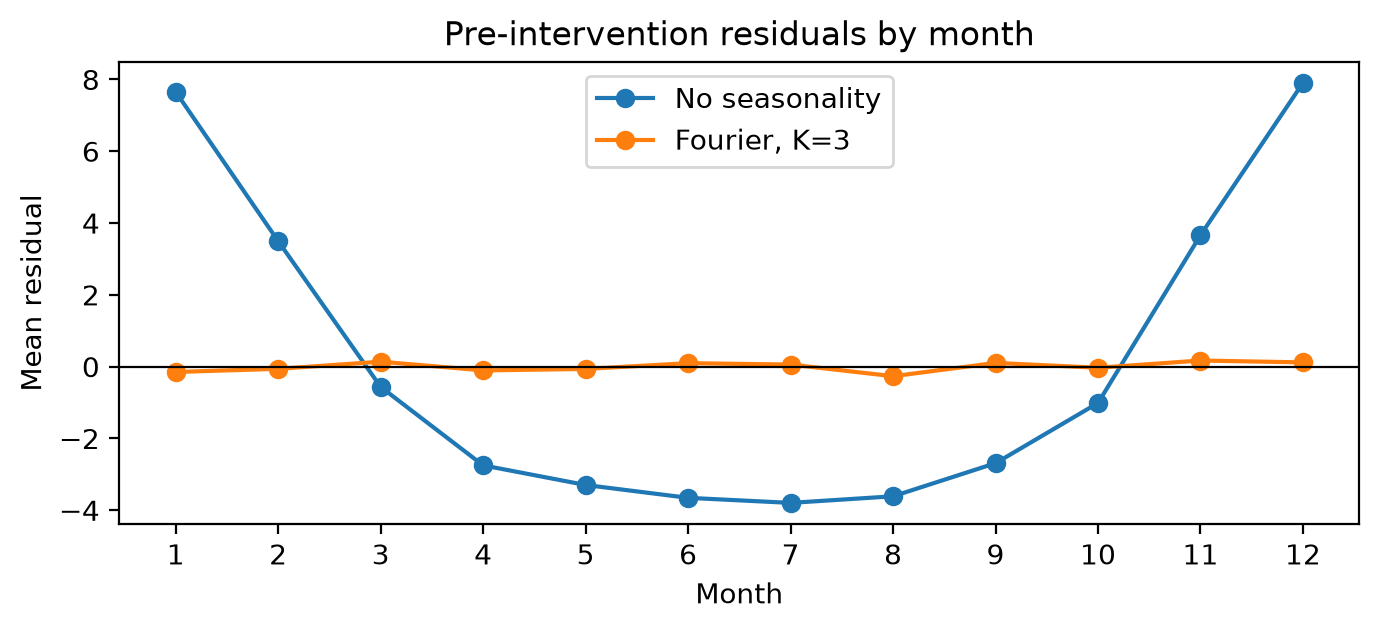

In [13]:
def monthly_residuals(result):
    plot_data = result.get_plot_data()
    pre_data = plot_data[plot_data.index < treatment_time]
    return pre_data.groupby(pre_data.index.month)["impact"].mean()


residuals = pd.DataFrame(
    {
        "No seasonality": monthly_residuals(result_trend),
        f"Fourier, K={k_best}": monthly_residuals(result_fourier),
    }
)
fig, ax = plt.subplots(figsize=(8, 3))
residuals.plot(ax=ax, marker="o")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="Month", ylabel="Mean residual", xticks=range(1, 13))
ax.set_title("Pre-intervention residuals by month");

The trend-only model's residuals rise in winter and fall in summer: the seasonal pattern it failed to capture. The residuals of the Fourier model stay close to zero in every month.

### Comparing specifications

The comparison below adds three alternatives: a single Fourier pair ($K=1$), more pairs than the criterion chose ($K=6$), and monthly dummies (`C(month)`), the approach used in the {doc}`interrupted-time-series-pymc` notebook.

In [14]:
specs = {
    "No seasonality": result_trend,
    "Fourier, K=1": fit_its(df, fourier_formula("y", 1)),
    f"Fourier, K={k_best}": result_fourier,
    "Fourier, K=6": fit_its(df, fourier_formula("y", 6)),
    "Month dummies": fit_its(df, "y ~ 1 + t + C(month)"),
}
comparison = pd.DataFrame({label: average_effect(r) for label, r in specs.items()}).T
comparison.round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


,mean,hdi_lower,hdi_upper
No seasonality,5.40,4.34,6.58
"Fourier, K=1",1.05,0.33,1.73
"Fourier, K=3",0.33,-0.16,0.77
"Fourier, K=6",0.28,-0.20,0.73
Month dummies,0.62,0.08,1.15


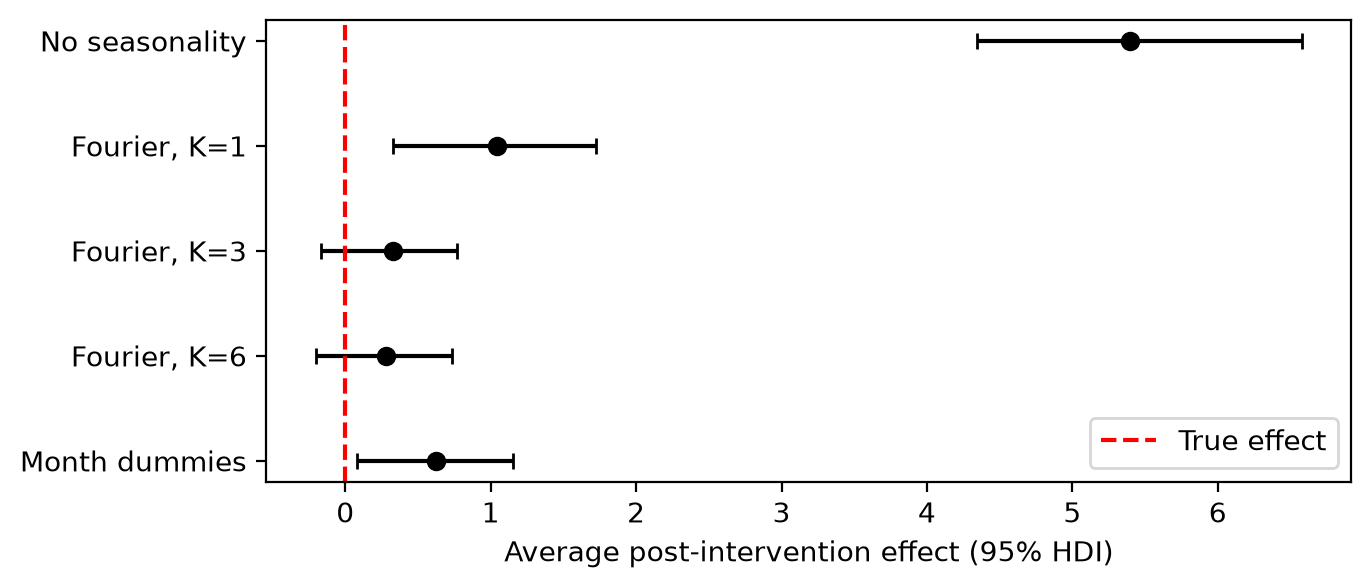

In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
y_pos = np.arange(len(comparison))
ax.errorbar(
    comparison["mean"],
    y_pos,
    xerr=[
        comparison["mean"] - comparison["hdi_lower"],
        comparison["hdi_upper"] - comparison["mean"],
    ],
    fmt="o",
    color="k",
    capsize=3,
)
ax.axvline(0, color="r", ls="--", label="True effect")
ax.set(
    yticks=y_pos,
    yticklabels=comparison.index,
    xlabel="Average post-intervention effect (95% HDI)",
)
ax.invert_yaxis()
ax.legend();

Four points stand out:

- Ignoring seasonality produces a large spurious effect.
- Too few Fourier pairs leave part of the bias: one pair cannot follow a sharp peak.
- More pairs than needed change the estimate very little: the extra coefficients are estimated close to zero. When in doubt, lean towards more pairs.
- Monthly dummies remove most of the bias, but their estimate stays a little further from zero than the Fourier models', and the Fourier model uses 6 parameters instead of 11. Dummies are the natural choice for monthly data; for weekly or daily data they impose a step-shaped pattern.

This is a single simulated dataset, so small non-zero estimates like these are expected from noise alone. The intervals describe uncertainty in the counterfactual, not the week-to-week noise in the observed post-intervention data, so even a well-specified model can produce an interval that narrowly misses zero.

### A placebo check at the same time in earlier years

If the model does not capture the seasonality, it will find an "effect" at the same time every year. A direct test is to move the treatment date to 1 December in earlier years. Each placebo dataset stops the same number of weeks after its fake treatment date as the real post-intervention period, so every placebo window covers December to March. For simplicity, the placebo fits reuse the number of Fourier pairs chosen on the full pre-intervention period.

In [16]:
post_weeks = int((df.index >= treatment_time).sum())
placebo_results, placebo_rows = {}, {}
for year in (2022, 2023, 2024):
    fake_time = pd.Timestamp(f"{year}-12-01")
    placebo_data = df[df.index < fake_time + pd.Timedelta(weeks=post_weeks)]
    for label, formula in {
        "No seasonality": "y ~ 1 + t",
        f"Fourier, K={k_best}": fourier_formula("y", k_best),
    }.items():
        result = fit_its(placebo_data, formula, treatment=fake_time)
        placebo_results[(year, label)] = result
        placebo_rows[(year, label)] = average_effect(result)
placebo = pd.DataFrame(placebo_rows).T.rename_axis(["placebo year", "model"])
placebo.round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


mean  hdi_lower  hdi_upper
placebo year model                                     
2022         No seasonality  6.77       5.08       8.50
             Fourier, K=3    0.49      -0.27       1.24
2023         No seasonality  6.34       4.91       7.79
             Fourier, K=3    0.46      -0.13       1.01
2024         No seasonality  5.41       4.07       6.58
             Fourier, K=3   -0.30      -0.80       0.22

The trend-only model finds a positive "effect" in every placebo December, the signature of uncaptured seasonality. The Fourier model's placebo effects are small, and their intervals include zero.

CausalPy's `PlaceboInTime` check automates placebo tests with a hierarchical summary of the placebo effects. By default, its fake treatment dates step back from the real one in windows about as long as the post-intervention period, so they do not land in the same season. For seasonal data, a same-season check like this one is a useful complement. See {doc}`sensitivity_checks` and the {doc}`interrupted-time-series-placebo-in-time-analysis` notebook.

## Seasonality and control series

In {term}`CITS <Comparative interrupted time-series>`, a control series enters the formula as a predictor, for example `treated ~ 1 + control`. The control absorbs any seasonality it shares with the treated series. It cannot absorb seasonality that is specific to the treated series, and whatever is left over can look like a treatment effect.

To show both cases, we simulate a control series with a twice-yearly pattern and two treated series:

- `treated_shared` depends on the control, so its only seasonality is the one it shares with the control.
- `treated_own` also has its own winter peak, which the control does not have.

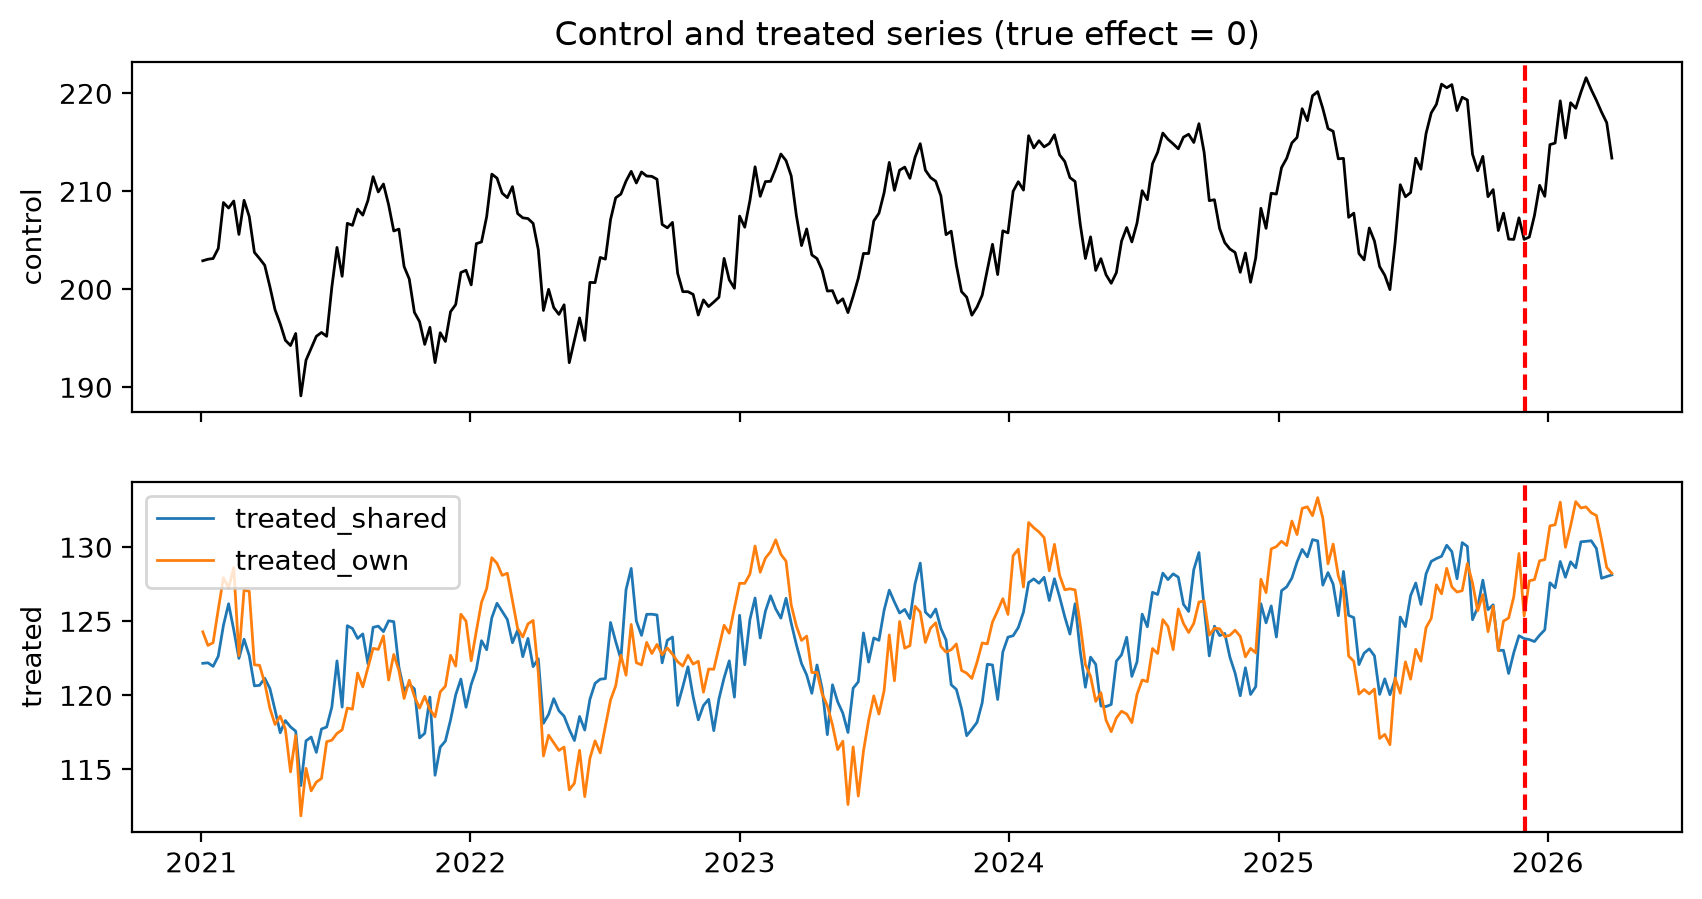

In [17]:
control = 200 + 0.05 * t + 8 * np.sin(2 * phase) + rng.normal(0, 1.5, len(dates))
own_season = 4 * np.cos(phase)

df_cits = pd.DataFrame(
    {
        "control": control,
        "treated_shared": 20 + 0.5 * control + rng.normal(0, 1, len(dates)),
        "treated_own": 20 + 0.5 * control + own_season + rng.normal(0, 1, len(dates)),
    },
    index=df.index,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(df_cits.index, df_cits["control"], color="k", lw=1)
axes[0].set(ylabel="control", title="Control and treated series (true effect = 0)")
for column in ["treated_shared", "treated_own"]:
    axes[1].plot(df_cits.index, df_cits[column], lw=1, label=column)
axes[1].set(ylabel="treated")
axes[1].legend()
for ax in axes:
    ax.axvline(treatment_time, color="r", ls="--")

We fit three models: each treated series with the control as the only predictor, and `treated_own` again with two Fourier pairs added.

In [18]:
df_cits = df_cits.join(fourier_features(df_cits.index, order=2))
cits_formulas = {
    "Shared seasonality, control only": "treated_shared ~ 1 + control",
    "Own seasonality, control only": "treated_own ~ 1 + control",
    "Own seasonality, control + Fourier (K=2)": fourier_formula(
        "treated_own", 2, base="1 + control"
    ),
}
cits_results = {label: fit_its(df_cits, f) for label, f in cits_formulas.items()}
pd.DataFrame({label: average_effect(r) for label, r in cits_results.items()}).T.round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


,mean,hdi_lower,hdi_upper
"Shared seasonality, control only",-0.12,-0.34,0.09
"Own seasonality, control only",2.90,2.26,3.48
"Own seasonality, control + Fourier (K=2)",-0.03,-0.36,0.25


When the seasonality is shared, the control removes it and the estimated effect is close to zero. When the treated series has its own seasonal pattern, the control cannot account for it and a spurious effect appears. Adding Fourier terms alongside the control removes it.

The size of the spurious effect is no accident: it is roughly the average of the seasonal component the control leaves out, taken over the post-intervention period.

In [19]:
post = df_cits.index >= treatment_time
print(
    f"average omitted seasonality over the post-intervention period: {own_season[post].mean():.2f}"
)

average omitted seasonality over the post-intervention period: 2.88


Shared seasonality rarely lines up perfectly. If the treated series peaks a few weeks earlier or later than the control, the control absorbs only the part of the pattern that coincides, so Fourier terms can still be needed alongside a good control. With real data, check the pre-intervention residuals of the CITS model by month, as above.

## Synthetic control

The same logic applies to {term}`synthetic control <Synthetic control>`, where the counterfactual is a weighted combination of {term}`donor units <Synthetic control>`. The weights are non-negative and sum to one, so the synthetic unit can only reproduce patterns inside the range spanned by the donors (the {term}`convex hull condition <Convex hull condition>`).

To show this, we simulate four donors that share the winter peak with different strengths, and two treated units:

- `treated_shared` is a weighted average of the donors, so its seasonality is inside the donors' range.
- `treated_own` adds a winter dip that no donor shows.

In [20]:
donors = pd.DataFrame(
    {
        name: level + trend * t + strength * seasonal + rng.normal(0, 1, len(dates))
        for name, level, trend, strength in [
            ("a", 90, 0.03, 0.6),
            ("b", 100, 0.02, 0.9),
            ("c", 110, 0.04, 1.1),
            ("d", 95, 0.03, 1.3),
        ]
    },
    index=df.index,
)
true_weights = np.array([0.4, 0.3, 0.2, 0.1])
sc_noise = rng.normal(0, 0.5, len(dates))
treated_shared = donors.to_numpy() @ true_weights + sc_noise
df_sc = donors.assign(
    treated_shared=treated_shared,
    treated_own=treated_shared - 4 * np.cos(phase),
)

sc_results = {
    unit: cp.SyntheticControl(
        df_sc,
        treatment_time,
        control_units=["a", "b", "c", "d"],
        treated_units=[unit],
        model=cp.pymc_models.WeightedSumFitter(
            sample_kwargs={
                "target_accept": 0.95,
                "random_seed": seed,
                "progressbar": False,
            }
        ),
    ).fit()
    for unit in ("treated_shared", "treated_own")
}
pd.DataFrame(
    {unit: average_effect(r, treated_unit=unit) for unit, r in sc_results.items()}
).T.round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


Sampling: [y_hat]


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


,mean,hdi_lower,hdi_upper
treated_shared,-0.27,-0.39,-0.14
treated_own,-3.12,-3.55,-2.74


The donors reproduce the shared seasonality, so the effect for `treated_shared` is small. No weighted average of the donors can produce the winter dip of `treated_own`, so its large negative effect is spurious.

The small effect for `treated_shared` still has an interval that excludes zero, for the reason given earlier: the interval describes uncertainty in the counterfactual, not the noise in the few observed post-intervention weeks. The model recovers the true donor weights closely, and the remaining gap matches the average noise of `treated_shared` over the post-intervention period:

In [21]:
weights = sc_results["treated_shared"].idata.posterior["beta"].mean(("chain", "draw"))
print("true donor weights:     ", true_weights)
print("posterior mean weights: ", np.round(weights.values.ravel(), 3))
print(
    f"average noise of treated_shared over the post-intervention period: {sc_noise[post].mean():.2f}"
)

true donor weights:      [0.4 0.3 0.2 0.1]
posterior mean weights:  [0.412 0.292 0.205 0.09 ]
average noise of treated_shared over the post-intervention period: -0.28


When donors do not share the treated unit's seasonal pattern, look for donors that do, or use a CITS model with Fourier terms as shown above. See the {doc}`synthetic-control-pymc` notebook for the full synthetic control workflow.

## Model-based seasonality

CausalPy also has time series models that estimate seasonality as part of the model rather than through formula columns:

- {class}`~causalpy.pymc_models.StateSpaceTimeSeries` is a Bayesian structural time series model with a local level or trend and a seasonal component whose period is set by `seasonal_length`. Its seasonal component can evolve over time. The {doc}`interrupted-time-series-causalpy-vs-causalimpact` notebook shows it in use.
- {class}`~causalpy.pymc_models.BayesianBasisExpansionTimeSeries` (experimental) combines a trend with changepoints and fixed yearly Fourier seasonality, with the number of Fourier components set by `n_order`. It is the approach of this notebook built into the model. Its default seasonality component requires the separate `pymc-marketing` package.
- {class}`~causalpy.pymc_forecast_models.PyMCForecastModel` wraps forecasting models from the optional `pymc-forecast` package, including models with stochastic seasonality.

Classes that are still experimental emit a `FutureWarning` when created. A seasonal component that can evolve is useful when the seasonal pattern changes over time, which fixed Fourier terms or dummies cannot capture.

## Practical notes

- **History.** Seasonal terms need several full seasonal cycles before the intervention; this example has almost five years. With fewer than two cycles, the seasonal terms and the trend are hard to tell apart.
- **Moving holidays.** Fourier terms follow the calendar date. Holidays whose date moves from year to year, such as Easter, Diwali or Lunar New Year, need their own indicator variables.

## Summary

| Design | How seasonality is handled | What to check |
|---|---|---|
| ITS | Add seasonal terms to the formula: Fourier pairs for weekly or daily data and smooth patterns, `C(month)` for monthly data | Choose $K$ on pre-intervention data only; check the pre-intervention residuals by month; run a same-season placebo check |
| CITS | The control absorbs shared seasonality | Seasonality specific to the treated series, or shifted in time, still needs seasonal terms |
| Synthetic control | Donors absorb shared seasonality | The treated unit's seasonal pattern must lie within the donors' range |
| Structural time series | The model estimates a seasonal component, which can evolve over time | Set `seasonal_length` to the number of observations per seasonal cycle |

## References

:::{bibliography}
:filter: docname in docnames
:::